# Fashion-MNIST Neural Network

Image classification with TensorFlow and Keras, adapted from Chapter 10 of *Hands-On Machine Learning with Scikit-Learn & TensorFlow*.

## Introduction

This notebook builds and trains neural networks with TensorFlow/Keras using both the Sequential model and functional API.

# Building an Image Classifier

First let's import TensorFlow and Keras. 

*Keras is now part of the TensorFlow library. It is also a standalone library. However it's best to not import the standalone library when using the TensorFlow version as there are some conflicts between the two versions of the Keras library.*

In [1]:
import tensorflow as tf
from tensorflow import keras

In [2]:
import numpy as np
import matplotlib.pyplot as plt

Let's start by loading the fashion MNIST dataset. Keras has a number of functions to load popular datasets in `keras.datasets`. The dataset is already split for you between a training set and a test set, but it can be useful to split the training set further to have a validation set:

In [3]:
fashion_mnist = keras.datasets.fashion_mnist
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

In [4]:
X_train_full.shape

(60000, 28, 28)

The training set contains 60,000 grayscale images, each 28x28 pixels:

In [5]:
X_train_full.dtype

dtype('uint8')

Each pixel intensity is represented as a byte (0 to 255):

Let's split the full training set into a validation set and a (smaller) training set. We also scale the pixel intensities down to the 0-1 range and convert them to floats, by dividing by 255.

In [6]:
X_valid, X_train = X_train_full[:5000] / 255., X_train_full[5000:] / 255.
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]
X_test = X_test / 255.

You can plot an image using Matplotlib's `imshow()` function, with a `'binary'`
 color map:

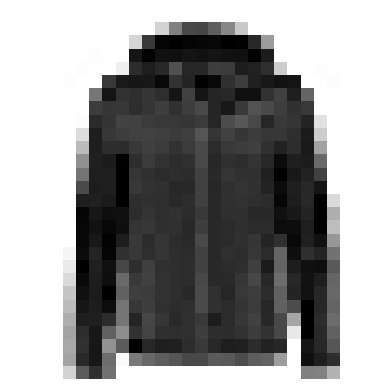

In [7]:
import matplotlib.pyplot as plt

plt.imshow(X_train[0], cmap="binary")
plt.axis('off')
plt.show()

The labels are the class IDs (represented as uint8), from 0 to 9:

In [8]:
# Labels for the first 20 training images
y_train[:20]

array([4, 0, 7, 9, 9, 9, 4, 4, 3, 4, 0, 1, 8, 6, 3, 6, 4, 3, 2, 8],
      dtype=uint8)

Here are the corresponding class names:

In [9]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

So the first image in the training set is a coat:

In [10]:
class_names[y_train[0]]

'Coat'

The validation set contains 5,000 images, and the test set contains 10,000 images:

In [11]:
X_valid.shape

(5000, 28, 28)

In [12]:
X_test.shape

(10000, 28, 28)

Let's take a look at a sample of the images in the dataset:

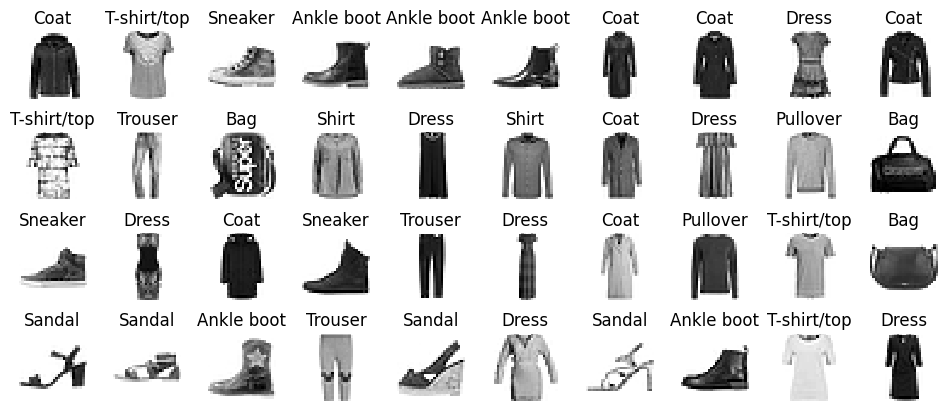

In [13]:
n_rows = 4
n_cols = 10
plt.figure(figsize=(n_cols * 1.2, n_rows * 1.2))
for row in range(n_rows):
    for col in range(n_cols):
        index = n_cols * row + col
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(X_train[index], cmap="binary", interpolation="nearest")
        plt.axis('off')
        plt.title(class_names[y_train[index]], fontsize=12)
plt.subplots_adjust(wspace=0.2, hspace=0.5)

plt.show()

## Creating a Neural net model in Keras
We are going to create a neural net model with the following properties:
- Input: Feature vector of pixel values for 28x28 grayscale image (28^2 = 784 features)
- Output: Class label. 10 classes (0 through 9).

Architecture:
1. Flatten 28x28 pixel images into 1-D feature vector of 784 features
2. Hidden layer 1: 300 units
3. Hidden layer 2: 100 units
4. Output layer: 10 units with Softmax activation

There are several ways we can create a neural net with this architecture. Since you may see all of them in practice, we will look at each one.


### Add layers one-by-one to a Sequential model
With this approach, we create a sequential model and add layers one at a time. This approach gives flexibility for when and how each layer is added.

In [14]:
model = keras.models.Sequential()

model.add(keras.layers.Flatten(input_shape=[28,28]))

# Hidden layers
model.add(keras.layers.Dense(300, activation='relu'))

model.add(keras.layers.Dense(100, activation='relu'))

# Output layer
model.add(keras.layers.Dense(10, activation='softmax'))

When experimenting with different architectures, we may create multiple models in a single notebook or program. When the previous model is no longer needed, it is a good idea to call `clear_session` to erase the current TensorFlow session graph used by the models. This frees memory and resets counters that are incremented as layers are created. 

In [15]:
keras.backend.clear_session()
np.random.seed(42)          # Reset NumPy's random number generator
tf.random.set_seed(42)      # Reset TensorFlow's random number generator

### Initialize sequential model with list of layers
With this approach, we create a sequential model and initialize it with a list of layers all at once. 

In [16]:
model = keras.models.Sequential([

keras.layers.Flatten(input_shape=[28,28]),

# Hidden layers
keras.layers.Dense(300, activation='relu'),

keras.layers.Dense(100, activation='relu'),

# Output layer
keras.layers.Dense(10, activation='softmax'),

])

In [17]:
model.layers

[<Flatten name=flatten, built=True>,
 <Dense name=dense, built=True>,
 <Dense name=dense_1, built=True>,
 <Dense name=dense_2, built=True>]

In [18]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

Each layer has a *name* attribute. You can specify the name to make it easier to find particular layers in a network.

In [19]:
hidden1 = model.layers[1]
hidden1.name

'dense'

You can access the current parameters in a layer with `get_weights()`.

In [20]:
w,b = hidden1.get_weights()

In [21]:
w

array([[ 0.04006896, -0.06297372,  0.06308073, ..., -0.02487214,
        -0.06762394,  0.01502077],
       [-0.03052207,  0.0605274 ,  0.05173205, ...,  0.0115893 ,
         0.01582039, -0.00918519],
       [-0.01244131,  0.03001706,  0.01940598, ...,  0.06179929,
         0.06698531,  0.02547887],
       ...,
       [ 0.01783407,  0.03338286,  0.01993731, ..., -0.05188204,
        -0.02012129,  0.06095999],
       [-0.06696931, -0.04246369, -0.02442114, ...,  0.00968508,
        -0.0687306 ,  0.05924478],
       [ 0.00511338, -0.04825494, -0.01355036, ..., -0.00019871,
         0.02684096, -0.00836571]], dtype=float32)

In [22]:
print(len(w))

784


In [23]:
print(len(b))

300


After creating the model, it is necessary to specify:
- Loss function
- Optimizer algorithm used to find the best weights during training
- Error metric(s) that will be calculated and reported when evaluating the model during training and prediction 

These key parameters are specified using the `compile()` function.

In [24]:
model.compile(loss=keras.losses.sparse_categorical_crossentropy,
              optimizer="sgd",
              metrics=["accuracy"])

This is equivalent to:

```python
model.compile(loss=keras.losses.sparse_categorical_crossentropy,
              optimizer=keras.optimizers.SGD(),
              metrics=[keras.metrics.sparse_categorical_accuracy])
```

To *train* the model, use the `fit()` function (similar to Scikit-Learn models).

In [25]:
history = model.fit(X_train, y_train, epochs=15, validation_data=(X_valid, y_valid))

Epoch 1/15
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.6786 - loss: 1.0202 - val_accuracy: 0.8202 - val_loss: 0.5167
Epoch 2/15
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8247 - loss: 0.5030 - val_accuracy: 0.8416 - val_loss: 0.4557
Epoch 3/15
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8410 - loss: 0.4499 - val_accuracy: 0.8502 - val_loss: 0.4244
Epoch 4/15
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8519 - loss: 0.4197 - val_accuracy: 0.8598 - val_loss: 0.4017
Epoch 5/15
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8595 - loss: 0.3977 - val_accuracy: 0.8636 - val_loss: 0.3870
Epoch 6/15
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8653 - loss: 0.3806 - val_accuracy: 0.8680 - val_loss: 0.3756
Epoch 7/15
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8698 - loss: 0.3666 - val_accuracy: 0.8726 - val_loss: 0.3649
Epoch 8/15
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8744 - loss: 0.3546 - 

Use `params` to see the training parameters used.

To access the loss and error metric values for each epoch, use `history`.

In [26]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

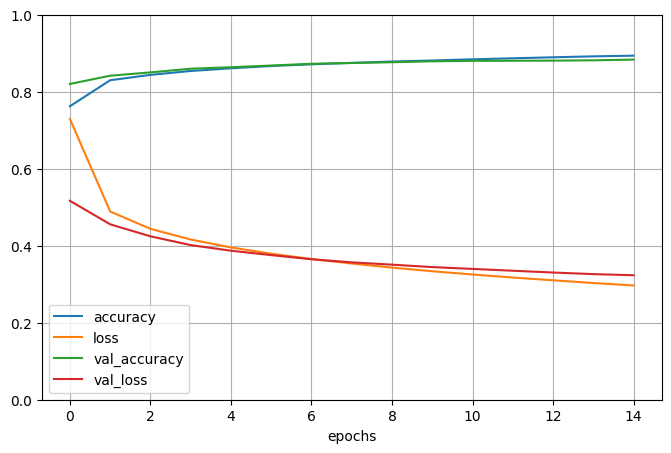

In [27]:
import pandas as pd

# Convert the training history to a DataFrame for plotting.
pd.DataFrame(history.history).plot(figsize=(8, 5))

plt.grid(True)
plt.gca().set_ylim(0, 1)
plt.xlabel('epochs')

plt.show()

Use `evaluate()` to make predictions on the test set and compute loss and error metrics.

In [28]:
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8720 - loss: 0.3596


[0.36073794960975647, 0.8708999752998352]

Use `predict()` to predict the output for given input instance(s).

In [29]:
X_new = X_test[:3]
y_proba = model.predict(X_new)
print(y_proba.round(2))
print(y_test[1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
[[0.   0.   0.   0.   0.   0.09 0.   0.04 0.   0.87]
 [0.   0.   0.99 0.   0.   0.   0.   0.   0.   0.  ]
 [0.   1.   0.   0.   0.   0.   0.   0.   0.   0.  ]]
2


`predict()` gave us the class probabilities for each input image. 

The predicted label is the class with the highest probability.



To get the *predicted label*  we can use the numpy `argmax()` function to find the class with the maximum probability for each image.

With `argmax()`, we specify the *axis* to compute the max over (axis=0 is row, axis=1 is column). 
- `axis=0` For each *column*, finds the *index* of the *row* with the max value
- `axis=1` For each *row*, finds the *index* of the *column* with the max value
- `axis=-1` Refers to the last (or highest numbered) axis. Argmax will operate over this axis. So for a *2D array*, `axis=-1` returns the same result as `axis=1` (i.e. operates over *columns*). This is useful when working with *N*-dimensional arrays (*tensors*). For example, arrays of images are 3D arrays. For more explanation, see https://stackoverflow.com/questions/47435526/what-is-the-meaning-of-axis-1-in-keras-argmax

In [30]:
a = np.array([[10,2,13],[4,15,6]])
print(a)

print('\nMax element in each column (axis=0, find max row in each column): \n{}'.format(np.max(a, axis=0)))
print('Max element in each row (axis=1, find max col for each row): \n{}'.format(np.max(a, axis=1)))
print('Max element in each row (axis=-1, operate over highest numbered axis (e.g. axis=1)): \n{}'.format(np.max(a, axis=-1)))

print('\nRow index of max element in each column (axis=0 (rows)): \n{}'.format(np.argmax(a, axis=0)))
print('Column index of max element in each row (axis=1 (cols)): \n{}'.format(np.argmax(a, axis=1)))
print('Column index of max element in each row (axis=-1 (cols for 2D arrays)): \n{}'.format(np.argmax(a, axis=-1)))


[[10  2 13]
 [ 4 15  6]]

Max element in each column (axis=0, find max row in each column): 
[10 15 13]
Max element in each row (axis=1, find max col for each row): 
[13 15]
Max element in each row (axis=-1, operate over highest numbered axis (e.g. axis=1)): 
[13 15]

Row index of max element in each column (axis=0 (rows)): 
[0 1 0]
Column index of max element in each row (axis=1 (cols)): 
[2 1]
Column index of max element in each row (axis=-1 (cols for 2D arrays)): 
[2 1]


In [31]:
y_pred = np.argmax(model.predict(X_new), axis=1)
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


array([9, 2, 1])

In [32]:
np.array(class_names)[y_pred]

array(['Ankle boot', 'Pullover', 'Trouser'], dtype='<U11')

In [33]:
y_new = y_test[:3]
y_new

array([9, 2, 1], dtype=uint8)

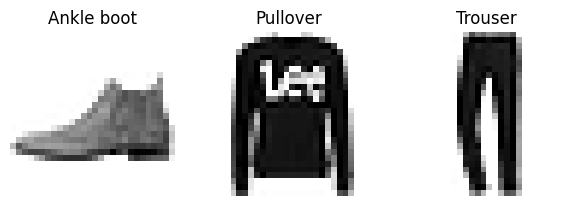

In [34]:
plt.figure(figsize=(7.2, 2.4))
for index, image in enumerate(X_new):
    plt.subplot(1, 3, index + 1)
    plt.imshow(image, cmap="binary", interpolation="nearest")
    plt.axis('off')
    plt.title(class_names[y_test[index]], fontsize=12)
    
plt.subplots_adjust(wspace=0.2, hspace=0.5)

plt.show()

# Regression MLP
The following section gives an example of a neural net for regression. 

The main difference between neural nets for regression vs. nets for classification is the activation function in the output layer (and the loss function used for training).
- *Regression activation function* is just a regular dense unit with *no activation* function specified. This allows the output value to range over *all possible real values*.
- *Classification networks* use either a *softmax* (multiclass) or *sigmoid* (binary classification).

Let's load, split and scale the California housing dataset (the original one, not the modified one as in chapter 2):

In [35]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

housing = fetch_california_housing()

X_train_full, X_test, y_train_full, y_test = train_test_split(housing.data, housing.target, random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(X_train_full, y_train_full, random_state=42)




In [36]:
np.random.seed(42)
tf.random.set_seed(42)

In [37]:
model = keras.models.Sequential([
    keras.layers.Dense(30, activation="relu"),
    keras.layers.Dense(1)
])

In [38]:
model.compile(loss="mean_squared_error", optimizer="adam")

In [39]:
history = model.fit(X_train, y_train, epochs=20, 
                    validation_data=(X_valid, y_valid))

Epoch 1/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 22.9087 - val_loss: 12.6031
Epoch 2/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4.6633 - val_loss: 2.5053
Epoch 3/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.7934 - val_loss: 3.0344
Epoch 4/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.8034 - val_loss: 3.0119
Epoch 5/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 3.1096 - val_loss: 2.6368
Epoch 6/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.0378 - val_loss: 3.2429
Epoch 7/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.9862 - val_loss: 4.8207
Epoch 8/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 3.3266 - val_loss: 4.1783
Epoch 9/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2.1310 - val_loss: 10.0483
Epoch 10/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4.5925 - val_loss: 5.4211
Epoch 11/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.5321 - val_loss: 2.4922
Epoch 12/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/s

         loss   val_loss
0   11.854476  12.603104
1    3.743884   2.505282
2    1.907835   3.034421
3    1.424331   3.011905
4    1.780250   2.636843
5    2.628346   3.242867
6    1.036849   4.820661
7    1.863354   4.178259
8    2.591775  10.048309
9    2.645471   5.421142
10   1.538779   2.492177
11   1.575916  14.319484
12   6.124237   2.431681
13   1.241454   3.350118
14   0.892079   2.267342
15   2.120830  10.526065
16   2.671462   5.339280
17   1.437476   2.367754
18   1.478757  12.121464
19   5.243732   2.631010


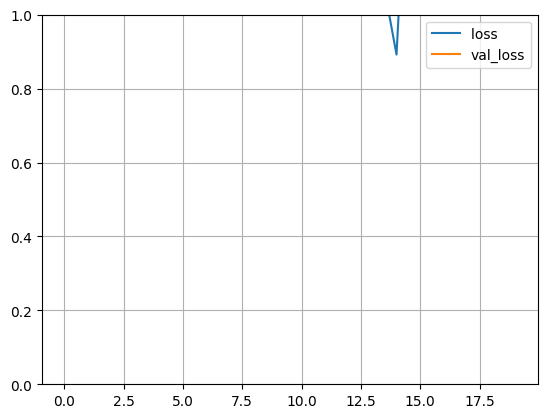

In [40]:
print(pd.DataFrame(history.history))

plt.plot(pd.DataFrame(history.history))
plt.legend(["loss ", "val_loss"])
plt.grid(True)
plt.gca().set_ylim(0, 1)
plt.show()

Since this is the same architecture and we used the same random seeds to start the random number generators, we should see the same results as before.

# Saving and Restoring

Depending on the complexity of the network and the amount of training data, train can take minutes, hours, days, or weeks.

When valuable time is spent training, it is important to be able to save the training progress. 

In [41]:
keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

In [42]:
model = keras.models.Sequential([
    keras.layers.Dense(30, activation="relu", input_shape=[8]),
    keras.layers.Dense(30, activation="relu"),
    keras.layers.Dense(1)
])    

In [43]:
model.compile(loss="mse", optimizer=keras.optimizers.SGD(learning_rate=1e-3))
history = model.fit(X_train, y_train, epochs=10, validation_data=(X_valid, y_valid))
mse_test = model.evaluate(X_test, y_test)

Epoch 1/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: nan - val_loss: nan
Epoch 2/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: nan - val_loss: nan
Epoch 3/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: nan - val_loss: nan
Epoch 4/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: nan - val_loss: nan
Epoch 5/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: nan - val_loss: nan
Epoch 6/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: nan - val_loss: nan
Epoch 7/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: nan - val_loss: nan
Epoch 8/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: nan - val_loss: nan
Epoch 9/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: nan - val_loss: nan
Epoch 10/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: nan - val_loss: nan
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: nan


To save our trained model (network architecture and weights), use the `save()` function.

In [44]:
model.save("my_keras_model.keras")

We can then use that trained model to make new predictions.

`load_model()` will load a trained model.

In [45]:
model2 = keras.models.load_model("my_keras_model.keras")

In [46]:
y_pred = model2.predict(X_test)

162/162 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [47]:
from sklearn.metrics import mean_squared_error

# The root mean squared error (RMSE)
print("Root mean squared error: %.2f"
      % np.sqrt(mean_squared_error(y_test, y_pred)))

In [ ]:
model2.compile(loss="mse", optimizer=keras.optimizers.SGD(learning_rate=1e-3))
history = model2.fit(X_train, y_train, epochs=10, validation_data=(X_valid, y_valid))
mse_test = model2.evaluate(X_test, y_test)

In [ ]:
y_pred = model2.predict(X_test)

In [ ]:
# The root mean squared error (RMSE)
print("Root mean squared error: %.2f"
      % np.sqrt(mean_squared_error(y_test, y_pred)))

`save()` saves the model architecture, training parameters and state, and weights.

If you just want to save the weights and nothing else, you can use `save_weights()`.

The weights may then be loaded into another model with the same architecture for prediction or transfer learning to a new task (e.g. start with pretrained network on one task, then optimize for new task).

In [ ]:
model.save_weights("my_keras_weights.ckpt")

In [ ]:
model.load_weights("my_keras_weights.ckpt")